In [1]:
import os

import matplotlib.pyplot as plt
from matplotlib import font_manager
import yabplot as yab

In [2]:
# Set root Dir for the project.
ROOT_DIR = "/Users/anthonygagnon/Documents/École/Université/Projects/nf-pediatric/"
RESULTS_DIR = ROOT_DIR + "nufo_experiment/"

# Dataset folder
PING_DATA = ROOT_DIR + "/PING/"
BCP_DATA = ROOT_DIR + "/BCP/"
BANDA_DATA = ROOT_DIR + "/BANDA/"
GESTE_DATA = ROOT_DIR + "/GESTE/"
ABCD_DATA = ROOT_DIR + "/ABCD/"
MYRNA_DATA = ROOT_DIR + "/MYRNA/"

# Create a directory for the results if it doesn't exist
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)

In [3]:
# Fetch Harding font.
font_files = []
for fontpath in font_manager.findSystemFonts(fontpaths=None, fontext='ttf'):
    if "Harding".lower() in fontpath.lower():
        font_files.append(fontpath)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# Set Harding font.
plt.rcParams['font.family'] = 'Harding Text Web'

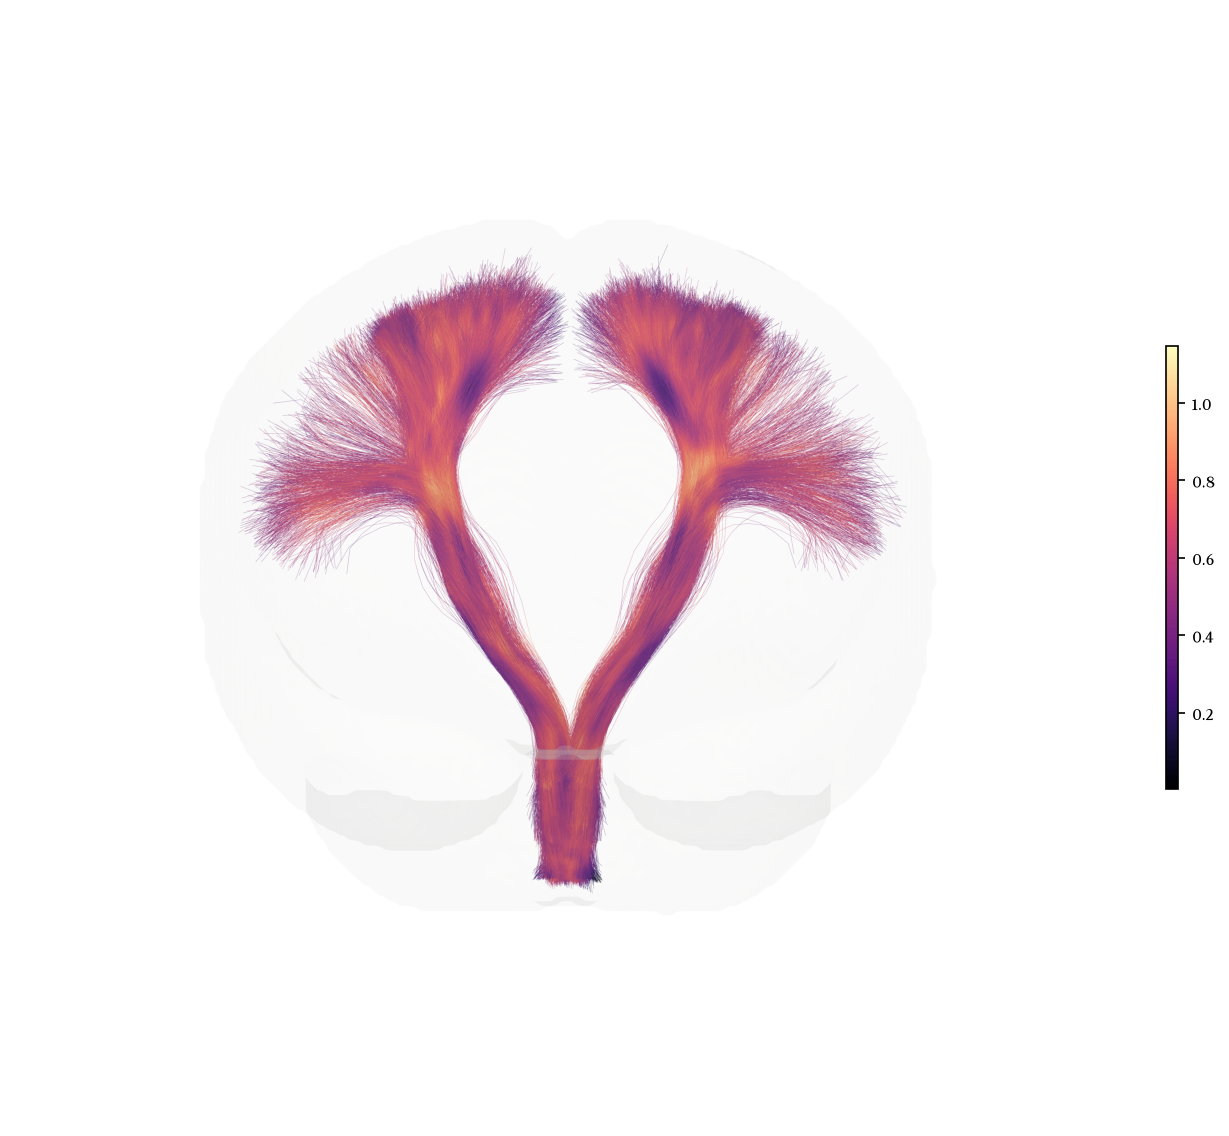

In [7]:
# Plot the PYT with nufo mapped.
nufo_nii = RESULTS_DIR + "average_diff_6mo.nii.gz"
bg_mesh = yab.load_nii_as_mesh(RESULTS_DIR + "tpl-UNCBCP4DInfant_cohort-03_desc-brain_T2w.nii.gz")

# map to the CST
cst_data = yab.project_vol2tract_atlas(nufo_nii, custom_atlas_path=RESULTS_DIR)

ax = yab.plot_tracts(
    custom_atlas_path=RESULTS_DIR,
    data=cst_data,
    bmesh=bg_mesh,
    cmap="magma",
    #vminmax=[0, 1],
    views=["anterior"],
    display_type="matplotlib",
    tract_kwargs={"render_lines_as_tubes": True, "line_width": 2},
    figsize=(10, 10),
    export_path=RESULTS_DIR + "cst_nufo_mapped.png",
)
plt.show()
plt.close()